In [ ]:
#By using GaussianNB, predict  have diabetes or not? (numerical features as input
# output:classification)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
df=pd.read_csv("/content/diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
# take numerical input features and output feature
# we select all columns of type 'int64' and 'float64' except for the target variable 'diabetes'
x = df.select_dtypes(include=['int64', 'float64']).drop(columns=['diabetes'])
y = df['diabetes']
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
le=LabelEncoder()
y_val=le.fit_transform(y)
# print(y_val)

In [ ]:
model=GaussianNB()
x_train,x_test,y_train,y_test=train_test_split(x,y_val)
#train model
model.fit(x_train,y_train)

y_pred=model.predict(x_test)#test output data

#accuracy score
acc=accuracy_score(y_test,y_pred)
print("Accuracy: ",acc)

Accuracy:  0.90284


In [49]:
# test
#get following user inputs
'''
age
hypertension
heart_disease
bmi
HbA1c_level
blood_glucose_level
'''

age=int(input("Enter age: "))
hypertension=int(input("Enter hypertension: "))
heart_disease=int(input("Enter heart disease: "))
bmi=float(input("Enter bmi: "))
HbA1c_level=float(input("Enter HbA1c level: "))
blood_glucose_level=int(input("Enter blood glucose level: "))

calc=pd.DataFrame([[age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level]],columns=x.columns)
calc

prediction=model.predict(calc)
if prediction[0]==1:
  print("The person is having diabetes")
else:
  print("The person is not having diabetes")

Enter age: 30
Enter hypertension: 1
Enter heart disease: 1
Enter bmi: 24.78
Enter HbA1c level: 6.1
Enter blood glucose level: 110
The person is having diabetes


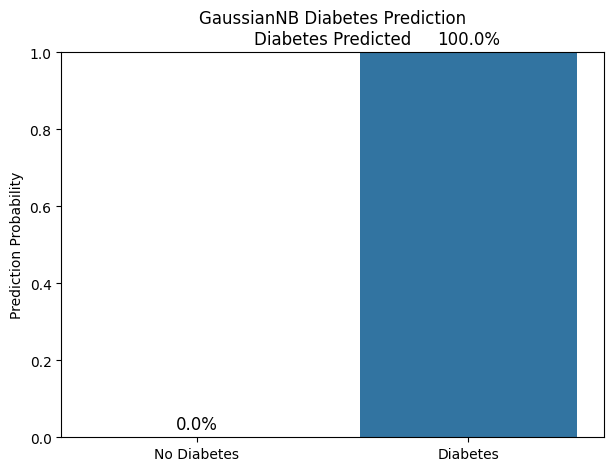

In [50]:

# Prediction probability
probability = model.predict_proba(calc)[0]




# Create visualization DataFrame
result = pd.DataFrame({
    "Prediction": ["No Diabetes", "Diabetes"],
    "Probability": probability
})

# Graph
plt.figure(figsize=(7, 5))

sns.barplot(data=result, x="Prediction",y="Probability")

# Add probability values

for i, value in enumerate(probability):
    plt.text(
        i,
        value + 0.02,
        f"{value:.1%}",
        ha="center",
        fontsize=12
    )

# Title based on prediction
if prediction[0] == 1:
    title = "Diabetes Predicted"
else:
    title = "No Diabetes Predicted"

plt.title(f"GaussianNB Diabetes Prediction\n{title}")
plt.ylabel("Prediction Probability")
plt.xlabel("")
plt.ylim(0, 1)
plt.show()